<a href="https://colab.research.google.com/github/francji1/01NAEX/blob/main/HW/01NAEX_Ex01_HW_Vesely.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01NAEX - Exercise 01: Simple comparative experiments

Data and exercises come from D. C. Montgomery: *Design and Analysis of Experiments*, 8th edition, Chapter 2.
Problem numbers follow the 8th edition.

**Homework solution:** Mateusz Vesely

## Learning goals

* Compare two treatments with the two-sample $t$-test (pooled and Welch) and interpret the $p$-value and the confidence interval.
* Test the equality of two variances with the $F$-test.
* Check the normality assumption (kernel density estimate, normal probability plot, Shapiro-Wilk test).
* Compute the power of a test and the sample size needed to reach a given power.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, t, f, shapiro
from statsmodels.stats.power import TTestIndPower

In [2]:
# --- Helper functions used in the homework solutions below ------------------------------------
# Fixed colours for the two groups in every figure (group 1 = blue, group 2 = orange)
COL_A, COL_B = "#2a78d6", "#eb6834"
plt.rcParams.update({"figure.figsize": (6.5, 4), "axes.grid": True, "grid.alpha": 0.3})


def describe(**samples):
    """Summary statistics (n, mean, sd, variance, min, max) of one or more samples."""
    rows = {name: {"n": len(x), "mean": np.mean(x), "sd": np.std(x, ddof=1),
                   "var": np.var(x, ddof=1), "min": np.min(x), "max": np.max(x)}
            for name, x in samples.items()}
    return pd.DataFrame(rows).T


def f_test_var(x, y):
    """Two-sided F-test of H0: var(x) = var(y). Returns F0, (df1, df2) and the P-value."""
    F0 = np.var(x, ddof=1) / np.var(y, ddof=1)
    df1, df2 = len(x) - 1, len(y) - 1
    p = 2 * min(f.cdf(F0, df1, df2), f.sf(F0, df1, df2))
    return F0, (df1, df2), p


def pooled_t(x, y, alpha=0.05, alternative="two-sided"):
    """Two-sample pooled t-test of H0: mu_x = mu_y with a (1 - alpha) confidence interval on mu_x - mu_y.

    alternative: "two-sided", "greater" (H1: mu_x > mu_y) or "less" (H1: mu_x < mu_y).
    """
    nx, ny = len(x), len(y)
    sp2 = ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2)
    se = np.sqrt(sp2 * (1 / nx + 1 / ny))
    diff = np.mean(x) - np.mean(y)
    df = nx + ny - 2
    t0 = diff / se
    if alternative == "two-sided":
        p = 2 * t.sf(abs(t0), df)
        ci = (diff - t.ppf(1 - alpha / 2, df) * se, diff + t.ppf(1 - alpha / 2, df) * se)
    elif alternative == "greater":
        p = t.sf(t0, df)
        ci = (diff - t.ppf(1 - alpha, df) * se, np.inf)
    else:
        p = t.cdf(t0, df)
        ci = (-np.inf, diff + t.ppf(1 - alpha, df) * se)
    return {"diff": diff, "sp": np.sqrt(sp2), "se": se, "df": df, "t0": t0, "p": p, "ci": ci}


def qq_plot(ax, x, label, color):
    """Normal probability (Q-Q) plot of x with the fitted straight line, drawn on the given axes."""
    (osm, osr), (slope, intercept, r) = stats.probplot(x, dist="norm")
    ax.plot(osm, osr, "o", color=color, ms=7, label=label)
    ax.plot(osm, slope * osm + intercept, color="0.4", lw=1.5)
    ax.set_xlabel("Theoretical quantiles (standard normal)")
    ax.set_ylabel("Ordered sample values")
    ax.set_title(f"Normal Q-Q plot: {label}  (r = {r:.3f})")


## Example from the lecture: Portland cement mortar

Lecture 1 compared the tension bond strength of a modified and an unmodified mortar formulation
(Montgomery, Example 2.1). We repeat the analysis in Python: $F$-test for the variances, two-sample $t$-tests,
confidence intervals, normality checks, and the power of the test.

In [3]:
# Data arrays
y1 = np.array([16.85,16.40,17.21,16.35,16.52,17.04,16.96,17.15,16.59,16.57])  # Modified Mortar
y2 = np.array([16.62,16.75,17.37,17.12,16.98,16.87,17.34,17.02,17.08,17.27])  # Unmodified Mortar

# Sample variances
s1_squared = np.var(y1, ddof=1)
s2_squared = np.var(y2, ddof=1)

# Degrees of freedom
dfn = len(y1) - 1  # Degrees of freedom numerator
dfd = len(y2) - 1  # Degrees of freedom denominator

# F-test statistic
F = s1_squared / s2_squared

# Two-tailed p-value
p_value = 2 * min(f.cdf(F, dfn, dfd), 1 - f.cdf(F, dfn, dfd))

print('F-statistic:', F)
print('Degrees of freedom:', dfn, 'and', dfd)
print('p-value:', p_value)

F-statistic: 1.6292573577265188
Degrees of freedom: 9 and 9
p-value: 0.47846033941944155


In [4]:
# 1. Two-sample t-test assuming equal variances (pooled; var.equal = TRUE in R)
t_stat_equal_var, p_value_equal_var = stats.ttest_ind(y1, y2, equal_var=True)

# Calculate confidence interval for equal variance
n1, n2 = len(y1), len(y2)
mean_diff = np.mean(y1) - np.mean(y2)
pooled_std = np.sqrt(((n1 - 1) * np.var(y1, ddof=1) + (n2 - 1) * np.var(y2, ddof=1)) / (n1 + n2 - 2))
se_pooled = pooled_std * np.sqrt(1/n1 + 1/n2)
conf_interval_equal_var = stats.t.interval(0.95, df=n1 + n2 - 2, loc=mean_diff, scale=se_pooled)

# 2. Welch's t-test (var.equal = FALSE in R)
t_stat_unequal_var, p_value_unequal_var = stats.ttest_ind(y1, y2, equal_var=False)
df_unequal_var = ((np.var(y1, ddof=1)/n1 + np.var(y2, ddof=1)/n2)**2) / \
                 ((np.var(y1, ddof=1)/n1)**2/(n1-1) + (np.var(y2, ddof=1)/n2)**2/(n2-1))

# Calculate confidence interval for unequal variance
se_unequal = np.sqrt(np.var(y1, ddof=1)/n1 + np.var(y2, ddof=1)/n2)
conf_interval_unequal_var = stats.t.interval(0.95, df=df_unequal_var, loc=mean_diff, scale=se_unequal)

# Results for t-test assuming equal variances
print("Two-Sample T-Test Assuming Equal Variances")
print(f"t-statistic: {t_stat_equal_var}")
print(f"p-value: {p_value_equal_var}")
print(f"95% confidence interval: {conf_interval_equal_var}")
print(f"Mean of y1: {np.mean(y1)}, Mean of y2: {np.mean(y2)}")
print()

# Results for Welch's t-test (unequal variances)
print("Welch's Two-Sample T-Test (Assuming Unequal Variances)")
print(f"t-statistic: {t_stat_unequal_var}")
print(f"p-value: {p_value_unequal_var}")
print(f"Degrees of freedom: {df_unequal_var}")
print(f"95% confidence interval: {conf_interval_unequal_var}")
print(f"Mean of y1: {np.mean(y1)}, Mean of y2: {np.mean(y2)}")


Two-Sample T-Test Assuming Equal Variances
t-statistic: -2.1868757949582633
p-value: 0.042196715924889903
95% confidence interval: (-0.5450733877678422, -0.010926612232162292)
Mean of y1: 16.764000000000003, Mean of y2: 17.042000000000005

Welch's Two-Sample T-Test (Assuming Unequal Variances)
t-statistic: -2.1868757949582633
p-value: 0.042998380088903033
Degrees of freedom: 17.02484516235282
95% confidence interval: (-0.5461741394750226, -0.009825860524981911)
Mean of y1: 16.764000000000003, Mean of y2: 17.042000000000005


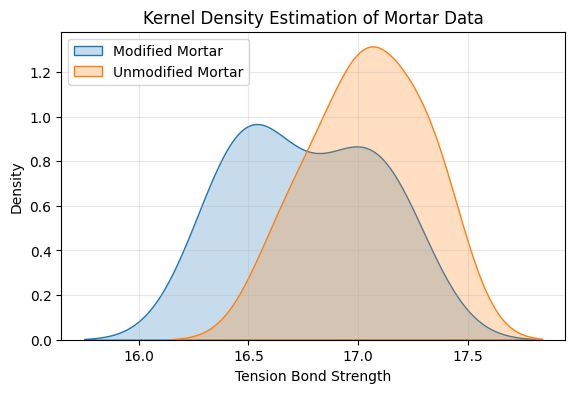

In [5]:
# Kernel Density Plot
sns.kdeplot(y1, fill=True, label='Modified Mortar')
sns.kdeplot(y2, fill=True, label='Unmodified Mortar')
plt.title('Kernel Density Estimation of Mortar Data')
plt.xlabel('Tension Bond Strength')
plt.legend()
plt.show()

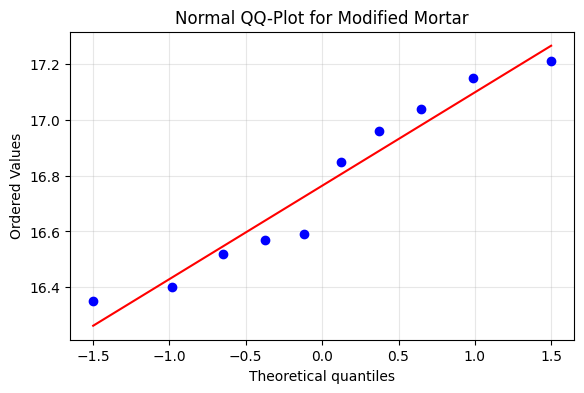

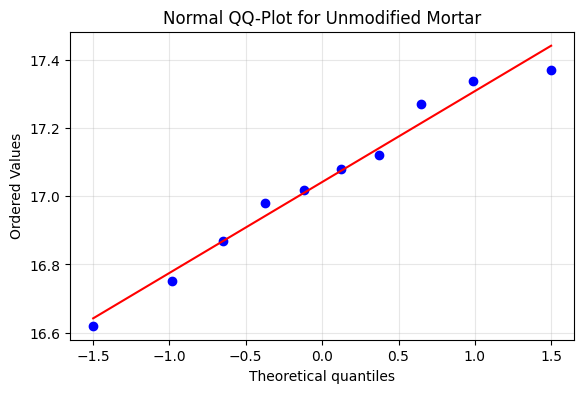

In [6]:
# QQ-Plot for y1
plt.figure()
stats.probplot(y1, dist="norm", plot=plt)
plt.title('Normal QQ-Plot for Modified Mortar')
plt.show()

# QQ-Plot for y2
plt.figure()
stats.probplot(y2, dist="norm", plot=plt)
plt.title('Normal QQ-Plot for Unmodified Mortar')
plt.show()

In [7]:
# Shapiro-Wilk test for y1
statistic_y1, p_value_y1 = shapiro(y1)
print(f'Shapiro-Wilk Test for y1: Statistic={statistic_y1}, p-value={p_value_y1}')

# Shapiro-Wilk test for y2
statistic_y2, p_value_y2 = shapiro(y2)
print(f'Shapiro-Wilk Test for y2: Statistic={statistic_y2}, p-value={p_value_y2}')

Shapiro-Wilk Test for y1: Statistic=0.9186332801846344, p-value=0.3456968630049325
Shapiro-Wilk Test for y2: Statistic=0.9626192871584892, p-value=0.8152773063551302


In [8]:
# Parameters
effect_size = (np.mean(y1) - np.mean(y2)) / np.sqrt((s1_squared + s2_squared) / 2)
alpha = 0.05
power = 0.95

# Create an instance of the power analysis class
analysis = TTestIndPower()

# Calculate required sample size
sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')
print(f'Required sample size per group: {np.ceil(sample_size)}')

# Calculate power of the test with n=10
actual_power = analysis.power(effect_size=effect_size, nobs1=10, alpha=alpha, alternative='two-sided')
print(f'Power of the test with n=10 per group: {actual_power}')

Required sample size per group: 29.0
Power of the test with n=10 per group: 0.543644223559894


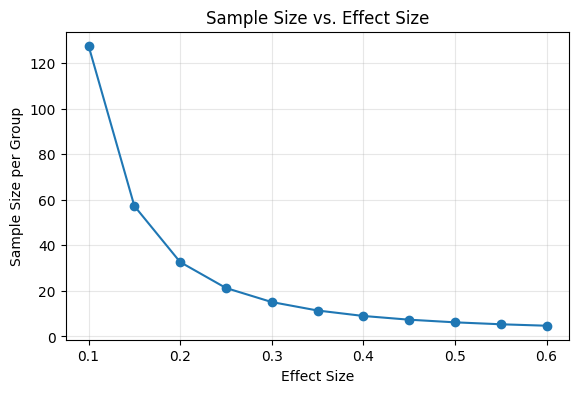

In [9]:
# Parameters
alpha = 0.05
power = 0.80
sd = 0.284  # Standard deviation
effect_sizes = np.array([0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6])

# Calculate sample sizes
analysis = TTestIndPower()
sample_sizes = []
for delta in effect_sizes:
    effect_size = delta / sd
    n = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')
    sample_sizes.append(n)

# Plotting
plt.plot(effect_sizes, sample_sizes, marker='o')
plt.xlabel('Effect Size')
plt.ylabel('Sample Size per Group')
plt.title('Sample Size vs. Effect Size')
plt.grid(True)
plt.show()


## Assignment

* Run the notebook above and get familiar with Python.
* Solve the following problems from Montgomery, *Design and Analysis of Experiments* (8th edition). Start in class and finish at home.
* Submit your solved notebook as a pull request into the `HW/` folder of the course repository, named
  `HW/01NAEX_Ex01_HW_<Surname>.ipynb` (see `HW/README.md`).
  **Deadline: Sunday 4 October 2026** (the next lecture is on 5 October; 28 September is a public holiday).

### Exercise 2.20

The shelf life of a carbonated beverage is of interest. Ten bottles are randomly selected and tested,
and the following results (in days) are obtained:

| | | | | |
|---|---|---|---|---|
| 108 | 124 | 124 | 106 | 115 |
| 138 | 163 | 159 | 134 | 139 |

* We would like to demonstrate that the mean shelf life exceeds 120 days. Set up appropriate hypotheses for investigating this claim.
* Test these hypotheses using significance level $\alpha = 0.01$. Find the P-value for the test. What are your conclusions?
* Construct a 99 percent confidence interval on the mean shelf life.
* Can shelf life be adequately described or modeled by a normal distribution? What effect would a violation of this assumption have on the test procedure you used in solving the previous questions?

In [10]:
# Read the data from the URL
url_20 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_20.csv"
df20 = pd.read_csv(url_20, sep=";")

# Display the first few rows of the dataframe
df20.head()


,Days
0,108
1,124
2,124
3,106
4,115


**Solution:**

**Hypotheses.** The goal is to *demonstrate* that the mean shelf life exceeds 120 days, so that claim is placed in the alternative hypothesis (the burden of proof is on $H_1$):

$$H_0:\ \mu = 120 \qquad\text{vs.}\qquad H_1:\ \mu > 120 .$$

The population variance is unknown and the sample is small ($n = 10$), so we use the one-sample $t$-test with

$$t_0 = \frac{\bar y - 120}{s/\sqrt{n}} \sim t_{n-1} = t_9 \quad \text{under } H_0 .$$

This is an upper-tail test: reject $H_0$ at $\alpha = 0.01$ if $t_0 > t_{0.01,\,9}$, equivalently if the $P$-value $= P(t_9 > t_0)$ is smaller than $0.01$.

In [11]:
y = df20["Days"].to_numpy(dtype=float)
n = len(y)
mu0, alpha = 120, 0.01

ybar, s = y.mean(), y.std(ddof=1)
se = s / np.sqrt(n)
t0 = (ybar - mu0) / se
t_crit = t.ppf(1 - alpha, n - 1)      # upper-tail critical value t(0.01, 9)
p_val = t.sf(t0, n - 1)               # P-value = P(t_9 > t0)

print(describe(shelf_life=y).round(3), "\n")
print(f"t0 = {t0:.3f}   critical value t(0.01, {n - 1}) = {t_crit:.3f}   P-value = {p_val:.4f}")
print(f"Reject H0 at alpha = {alpha}?  {'YES' if p_val < alpha else 'NO'}")

# cross-check with scipy
res = stats.ttest_1samp(y, popmean=mu0, alternative="greater")
print(f"scipy ttest_1samp: t = {res.statistic:.3f}, P-value = {res.pvalue:.4f}")

               n   mean      sd    var    min    max
shelf_life  10.0  131.0  19.545  382.0  106.0  163.0 

t0 = 1.780   critical value t(0.01, 9) = 2.821   P-value = 0.0544
Reject H0 at alpha = 0.01?  NO
scipy ttest_1samp: t = 1.780, P-value = 0.0544


In [12]:
# 99% (two-sided) confidence interval on the mean shelf life
ci_lo, ci_hi = t.interval(0.99, df=n - 1, loc=ybar, scale=se)
print(f"99% confidence interval for mu: ({ci_lo:.2f}, {ci_hi:.2f}) days")

# one-sided 99% lower confidence bound (the interval that corresponds to the one-sided test)
lower = ybar - t.ppf(0.99, n - 1) * se
print(f"99% lower confidence bound:     mu >= {lower:.2f} days")

99% confidence interval for mu: (110.91, 151.09) days
99% lower confidence bound:     mu >= 113.56 days


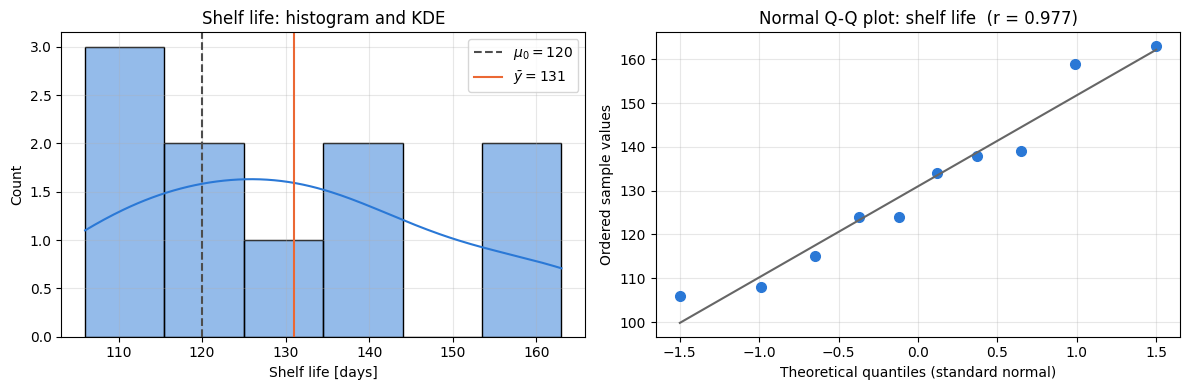

Shapiro-Wilk: W = 0.9365, P-value = 0.5152  ->  normality not rejected at the 5% level
Wilcoxon signed-rank test (H1: median > 120): W = 42.5, P-value = 0.0801


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(y, bins=6, kde=True, color=COL_A, ax=axes[0])
axes[0].axvline(mu0, color="0.3", ls="--", label=r"$\mu_0 = 120$")
axes[0].axvline(ybar, color=COL_B, label=rf"$\bar y = {ybar:.0f}$")
axes[0].set(xlabel="Shelf life [days]", ylabel="Count", title="Shelf life: histogram and KDE")
axes[0].legend()

qq_plot(axes[1], y, "shelf life", COL_A)
plt.tight_layout()
plt.show()

W, p_sw = shapiro(y)
print(f"Shapiro-Wilk: W = {W:.4f}, P-value = {p_sw:.4f}  ->  normality {'rejected' if p_sw < 0.05 else 'not rejected'} at the 5% level")

# distribution-free cross-check: Wilcoxon signed-rank test of H0: median = 120 vs H1: median > 120
w_stat, p_w = stats.wilcoxon(y - mu0, alternative="greater")
print(f"Wilcoxon signed-rank test (H1: median > 120): W = {w_stat:.1f}, P-value = {p_w:.4f}")

**Conclusions (Exercise 2.20)**

* **Test.** $\bar y = 131.0$ days, $s = 19.54$ days, $t_0 = 1.78$. Since $t_0 < t_{0.01,9} = 2.82$ and the $P$-value is $0.054 > 0.01$, we **do not reject $H_0$**: at the 1% level there is not enough evidence that the mean shelf life exceeds 120 days. The sample mean is above 120, but with only 10 bottles and $s \approx 20$ days the evidence is weak (the result would be borderline even at $\alpha = 0.05$).
* **Confidence interval.** $110.9 \le \mu \le 151.1$ days (99%). The interval contains 120, consistent with the test. The one-sided 99% bound $\mu \ge 113.6$ does not exclude 120 either.
* **Normality.** The Q-Q plot is close to a straight line and the Shapiro-Wilk test does not reject normality ($P = 0.52$), so the normal model is adequate as far as 10 observations can tell. The histogram hints at two groups of bottles (106–124 and 134–163 days), but with $n = 10$ this cannot be distinguished from sampling noise.
* **Effect of a violation.** The $t$-test is exact only for normal data. It is fairly robust to moderate departures because $\bar y$ is approximately normal by the central limit theorem, but with $n = 10$ heavy tails or strong skewness would make the true type I error rate differ from the nominal $\alpha$ and would reduce the power; outliers inflate $s$ and shrink $t_0$. If normality were doubtful, a distribution-free procedure should be used, e.g. the Wilcoxon signed-rank test (here $P = 0.08$, same conclusion), or a bootstrap confidence interval.

### Exercise 2.21

In semiconductor manufacturing, wet chemical etching is often used to remove silicon from the backs of wafers prior to metallization. The **etch rate** is an important characteristic of this process. Two different etching solutions are being evaluated. Eight randomly selected wafers have been etched in each solution and the observed etch rates (in mils/min) are shown below:

| Solution 1 | Solution 2 |
|------------|------------|
|  9.9       | 10.2       |
|  9.4       | 10.0       |
| 10.0       | 10.7       |
| 10.3       | 10.5       |
| 10.6       | 10.6       |
| 10.3       | 10.2       |
|  9.3       | 10.4       |
|  9.8       | 10.3       |

**(a)** Do the data indicate that the claim that both solutions have the same mean etch rate is valid? Use α = 0.05 and assume equal variances.  

**(b)** Find a 95% confidence interval on the difference in mean etch rates.  

**(c)** Use normal probability plots to investigate the adequacy of the assumptions of normality and equal variances.  

**(d)** Compute the power of the test in part (a). Assume that the true difference in means and the common variance equal the estimates obtained from the data. How many observations per group would be required to achieve power greater than 0.9 to detect a difference of Δ = 0.3 at significance level α = 0.05?


In [14]:
# Read the data from the URL
url_21 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_21.csv"
df21 = pd.read_csv(url_21, sep=";")

# Display the first few rows of the dataframe
df21.head()

,Solution1,Solution2
0,9.9,10.2
1,9.4,10.0
2,10.0,10.7
3,10.3,10.5
4,10.6,10.6


**Solution:**

**Hypotheses.** Let $\mu_1, \mu_2$ be the mean etch rates of solutions 1 and 2. The claim "both solutions have the same mean etch rate" is tested as

$$H_0:\ \mu_1 = \mu_2 \qquad\text{vs.}\qquad H_1:\ \mu_1 \ne \mu_2 .$$

With equal variances assumed, the pooled two-sample $t$-test uses

$$t_0 = \frac{\bar y_1 - \bar y_2}{S_p\sqrt{1/n_1 + 1/n_2}}, \qquad S_p^2 = \frac{(n_1-1)S_1^2 + (n_2-1)S_2^2}{n_1+n_2-2}, \qquad t_0 \sim t_{n_1+n_2-2} = t_{14} \text{ under } H_0 .$$

Reject $H_0$ at $\alpha = 0.05$ if $|t_0| > t_{0.025,\,14} = 2.145$.

In [15]:
y1 = df21["Solution1"].to_numpy(dtype=float)
y2 = df21["Solution2"].to_numpy(dtype=float)
n1, n2 = len(y1), len(y2)
alpha = 0.05

print(describe(solution_1=y1, solution_2=y2).round(4), "\n")

# F-test of equal variances (justifies the pooled test)
F0, (d1, d2), p_F = f_test_var(y1, y2)
print(f"F-test for equal variances: F0 = {F0:.3f}, df = ({d1}, {d2}), P-value = {p_F:.3f}  ->  "
      f"equal variances {'rejected' if p_F < alpha else 'not rejected'}")

# (a) pooled two-sample t-test
r = pooled_t(y1, y2, alpha=alpha)
t_crit = t.ppf(1 - alpha / 2, r["df"])
print(f"\nPooled t-test: ybar1 - ybar2 = {r['diff']:.4f}, Sp = {r['sp']:.4f}, se = {r['se']:.4f}")
print(f"t0 = {r['t0']:.3f}, df = {r['df']}, critical value t(0.025, 14) = {t_crit:.3f}, P-value = {r['p']:.4f}")
print(f"Reject H0 at alpha = {alpha}?  {'YES' if r['p'] < alpha else 'NO'}")

# cross-check with scipy
res = stats.ttest_ind(y1, y2, equal_var=True)
print(f"scipy ttest_ind (pooled): t = {res.statistic:.3f}, P-value = {res.pvalue:.4f}")

              n     mean      sd     var   min   max
solution_1  8.0   9.9500  0.4504  0.2029   9.3  10.6
solution_2  8.0  10.3625  0.2326  0.0541  10.0  10.7 

F-test for equal variances: F0 = 3.749, df = (7, 7), P-value = 0.102  ->  equal variances not rejected

Pooled t-test: ybar1 - ybar2 = -0.4125, Sp = 0.3584, se = 0.1792
t0 = -2.302, df = 14, critical value t(0.025, 14) = 2.145, P-value = 0.0372
Reject H0 at alpha = 0.05?  YES
scipy ttest_ind (pooled): t = -2.302, P-value = 0.0372


In [16]:
# (b) 95% confidence interval on mu1 - mu2 (pooled)
lo, hi = r["ci"]
print(f"95% CI for mu1 - mu2: ({lo:.3f}, {hi:.3f}) mils/min")
print(f"scipy: {res.confidence_interval(0.95)}")

95% CI for mu1 - mu2: (-0.797, -0.028) mils/min
scipy: ConfidenceInterval(low=-0.7968930221925354, high=-0.02810697780746746)


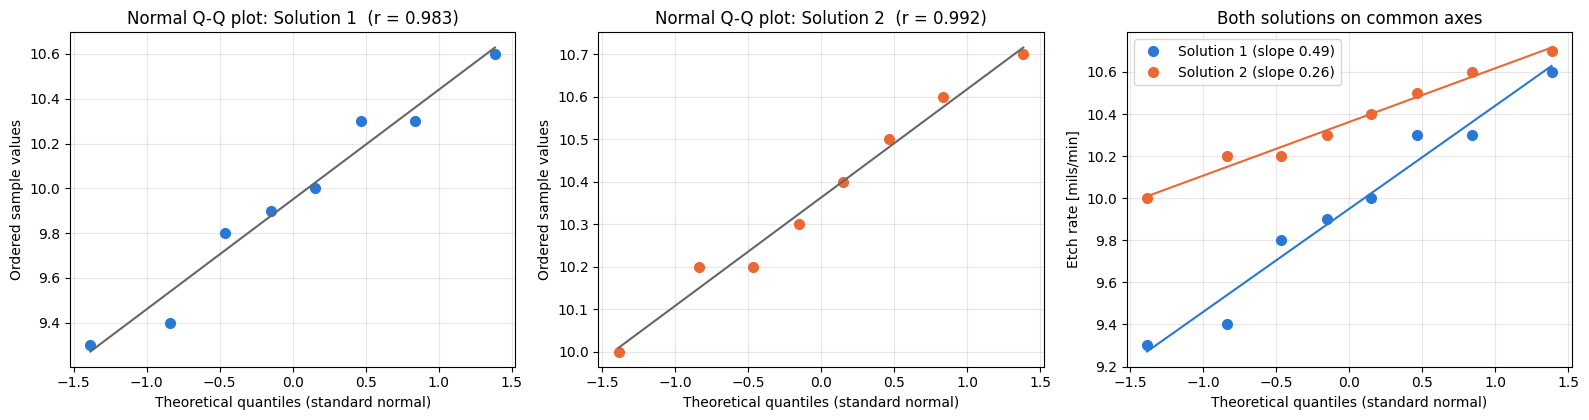

Shapiro-Wilk Solution 1: W = 0.9549, P-value = 0.760
Shapiro-Wilk Solution 2: W = 0.9768, P-value = 0.945


In [17]:
# (c) normal probability plots: one per solution, and both on common axes
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
qq_plot(axes[0], y1, "Solution 1", COL_A)
qq_plot(axes[1], y2, "Solution 2", COL_B)

# common axes: the slope of each fitted line estimates the standard deviation of that group
# (least-squares slope of the ordered values against the normal quantiles, close to but not equal to s)
for data, label, col in [(y1, "Solution 1", COL_A), (y2, "Solution 2", COL_B)]:
    (osm, osr), (slope, intercept, _) = stats.probplot(data, dist="norm")
    axes[2].plot(osm, osr, "o", color=col, ms=7, label=f"{label} (slope {slope:.2f})")
    axes[2].plot(osm, slope * osm + intercept, color=col, lw=1.5)
axes[2].set(xlabel="Theoretical quantiles (standard normal)", ylabel="Etch rate [mils/min]",
            title="Both solutions on common axes")
axes[2].legend()
plt.tight_layout()
plt.show()

for data, label in [(y1, "Solution 1"), (y2, "Solution 2")]:
    W, p_sw = shapiro(data)
    print(f"Shapiro-Wilk {label}: W = {W:.4f}, P-value = {p_sw:.3f}")

Observed difference = 0.4125, Sp = 0.3584, effect size d = 1.151
Power of the test in (a) with n = 8 per group: 0.572
Check via non-central t (ncp = 2.302): power = 0.572

To detect Delta = 0.3 with power 0.9: n = 31.0  ->  31 wafers per group
   power with n = 30: 0.890
   power with n = 31: 0.900


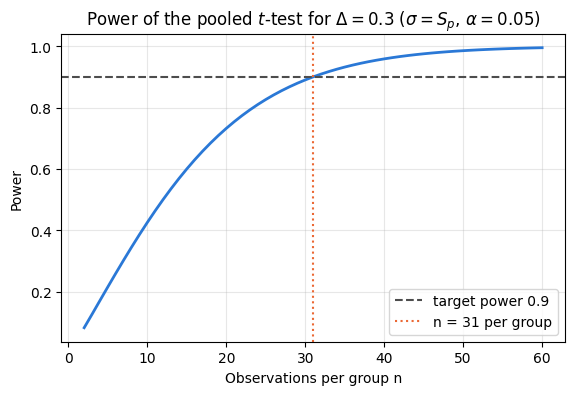

In [18]:
# (d) power of the test in (a): true difference and common variance = the sample estimates
analysis = TTestIndPower()
delta_hat, sigma_hat = abs(r["diff"]), r["sp"]
d_hat = delta_hat / sigma_hat                                   # standardised effect size (Cohen's d)
power_a = analysis.power(effect_size=d_hat, nobs1=n1, ratio=n2 / n1, alpha=alpha, alternative="two-sided")
print(f"Observed difference = {delta_hat:.4f}, Sp = {sigma_hat:.4f}, effect size d = {d_hat:.3f}")
print(f"Power of the test in (a) with n = {n1} per group: {power_a:.3f}")

# the same number computed directly from the non-central t distribution
ncp = delta_hat / (sigma_hat * np.sqrt(1 / n1 + 1 / n2))
tc = t.ppf(1 - alpha / 2, n1 + n2 - 2)
power_nct = stats.nct.sf(tc, n1 + n2 - 2, ncp) + stats.nct.cdf(-tc, n1 + n2 - 2, ncp)
print(f"Check via non-central t (ncp = {ncp:.3f}): power = {power_nct:.3f}")

# sample size per group for power > 0.9 when Delta = 0.3
n_req = analysis.solve_power(effect_size=0.3 / sigma_hat, alpha=alpha, power=0.9, alternative="two-sided")
print(f"\nTo detect Delta = 0.3 with power 0.9: n = {n_req:.1f}  ->  {int(np.ceil(n_req))} wafers per group")
for nn in (int(np.ceil(n_req)) - 1, int(np.ceil(n_req))):
    print(f"   power with n = {nn}: {analysis.power(effect_size=0.3 / sigma_hat, nobs1=nn, alpha=alpha):.3f}")

# power curve versus sample size for Delta = 0.3
ns = np.arange(2, 61)
pw = analysis.power(effect_size=0.3 / sigma_hat, nobs1=ns, alpha=alpha, alternative="two-sided")
plt.figure(figsize=(6.5, 4))
plt.plot(ns, pw, color=COL_A, lw=2)
plt.axhline(0.9, color="0.3", ls="--", label="target power 0.9")
plt.axvline(np.ceil(n_req), color=COL_B, ls=":", label=f"n = {int(np.ceil(n_req))} per group")
plt.xlabel("Observations per group n")
plt.ylabel("Power")
plt.title(r"Power of the pooled $t$-test for $\Delta = 0.3$ ($\sigma = S_p$, $\alpha = 0.05$)")
plt.legend()
plt.show()

**Conclusions (Exercise 2.21)**

* **(a)** $\bar y_1 = 9.950$, $\bar y_2 = 10.363$, $S_p = 0.358$, $t_0 = -2.30$ with 14 degrees of freedom. Since $|t_0| > 2.145$ ($P = 0.037 < 0.05$), we **reject $H_0$**: the data do not support the claim that the two solutions have the same mean etch rate. Solution 2 etches faster on average. (The $F$-test gives $P = 0.10$, so the equal-variance assumption is not contradicted and the pooled test is appropriate.)
* **(b)** $-0.80 \le \mu_1 - \mu_2 \le -0.03$ mils/min (95%). The interval excludes 0, in agreement with (a), but its upper limit is close to 0: the difference is statistically significant but not estimated very precisely.
* **(c)** Both normal probability plots are approximately linear and the Shapiro-Wilk tests do not reject normality ($P = 0.76$ and $0.95$), so normality is adequate. On the common axes the fitted line for solution 1 is about twice as steep as for solution 2 (slopes 0.49 vs. 0.26; the slope estimates $\sigma$, cf. $s_1 = 0.45$ and $s_2 = 0.23$); with $n = 8$ per group this is within sampling variation ($F$-test $P = 0.10$), so the equal-variance assumption is acceptable, although it is the weaker of the two assumptions here. Welch's test gives $P = 0.043$ and the same conclusion.
* **(d)** With $\Delta = |\bar y_1 - \bar y_2| = 0.41$ and $\sigma = S_p = 0.36$ the power of the test in (a) is only **0.57**: an experiment of this size would miss a true difference of this magnitude about 43% of the time. To detect $\Delta = 0.3$ with power at least 0.9 at $\alpha = 0.05$ we need **$n = 31$ wafers per group** (power 0.890 at $n = 30$, 0.900 at $n = 31$).


### Exercise 2.26

The following are the burning times (in minutes) of chemical flares of two different formulations. The design engineers are interested in both the mean and
variance of the burning times.

|Type1|   | Type2 | |
|----|----|----|----|
| 65 | 82 | 64 | 56 |
| 81 | 67 | 71 | 69 |
| 57 | 59 | 83 | 74 |
| 66 | 75 | 59 | 82 |
| 82 | 70 | 65 | 79 |


1. Test the hypothesis that the two variances are equal. Use $\alpha = 0.05$.
2. Using the results of part 1), test the hypothesis that the mean burning
times are equal. Use $\alpha = 0.05$. What is the P-value for this test?
3. Discuss the role of the normality assumption in this problem. Check the
assumption of normality for both types of flares
4. If the mean burning times of the two flares differ by as much as 2 minutes, find the power of the test. What sample size would be required to detect an actual difference in mean burning time of 1 minute with a power of at least 0.9?

In [19]:
# Read the data from the URL
url_26 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_26.csv"
df26 = pd.read_csv(url_26, sep=";")

# Display the first few rows of the dataframe
df26.head()

,Type1,Type2
0,65,64
1,81,71
2,57,83
3,66,59
4,82,65


**Solution:**

**Hypotheses.** Let $\sigma_1^2, \sigma_2^2$ and $\mu_1, \mu_2$ be the variances and the means of the burning times of the two formulations.

1. Equality of variances: $H_0:\ \sigma_1^2 = \sigma_2^2$ vs. $H_1:\ \sigma_1^2 \ne \sigma_2^2$, tested with $F_0 = S_1^2/S_2^2 \sim F_{n_1-1,\,n_2-1} = F_{9,9}$ under $H_0$. Reject at $\alpha = 0.05$ if $F_0 > F_{0.025,9,9}$ or $F_0 < F_{0.975,9,9}$.
2. Equality of means: $H_0:\ \mu_1 = \mu_2$ vs. $H_1:\ \mu_1 \ne \mu_2$. The test depends on the outcome of 1: the pooled $t$-test if equal variances are not rejected, Welch's $t$-test otherwise.

In [20]:
y1 = df26["Type1"].to_numpy(dtype=float)
y2 = df26["Type2"].to_numpy(dtype=float)
n1, n2 = len(y1), len(y2)
alpha = 0.05

print(describe(type_1=y1, type_2=y2).round(3), "\n")

# 1) F-test for equality of variances
F0, (d1, d2), p_F = f_test_var(y1, y2)
F_lo, F_hi = f.ppf(alpha / 2, d1, d2), f.ppf(1 - alpha / 2, d1, d2)
print(f"F0 = S1^2 / S2^2 = {F0:.3f}, df = ({d1}, {d2}), P-value = {p_F:.3f}")
print(f"Rejection region: F0 < {F_lo:.3f} or F0 > {F_hi:.3f}")
print(f"Reject H0 (equal variances) at alpha = {alpha}?  {'YES' if p_F < alpha else 'NO'}")

# alternatives to the F-test that are less sensitive to non-normality
lev = stats.levene(y1, y2, center="median")
bar = stats.bartlett(y1, y2)
print(f"Levene (Brown-Forsythe): P-value = {lev.pvalue:.3f};  Bartlett: P-value = {bar.pvalue:.3f}")

           n  mean     sd     var   min   max
type_1  10.0  70.4  9.264  85.822  57.0  82.0
type_2  10.0  70.2  9.367  87.733  56.0  83.0 

F0 = S1^2 / S2^2 = 0.978, df = (9, 9), P-value = 0.974
Rejection region: F0 < 0.248 or F0 > 4.026
Reject H0 (equal variances) at alpha = 0.05?  NO
Levene (Brown-Forsythe): P-value = 1.000;  Bartlett: P-value = 0.974


In [21]:
# 2) equal variances were not rejected -> pooled two-sample t-test
r = pooled_t(y1, y2, alpha=alpha)
t_crit = t.ppf(1 - alpha / 2, r["df"])
print(f"ybar1 - ybar2 = {r['diff']:.3f} min, Sp = {r['sp']:.3f} min, se = {r['se']:.3f}")
print(f"t0 = {r['t0']:.3f}, df = {r['df']}, critical value t(0.025, 18) = {t_crit:.3f}, P-value = {r['p']:.3f}")
print(f"95% CI for mu1 - mu2: ({r['ci'][0]:.2f}, {r['ci'][1]:.2f}) min")
print(f"Reject H0 (equal means) at alpha = {alpha}?  {'YES' if r['p'] < alpha else 'NO'}")

# Welch's test for comparison (it would be used if the variances differed)
res_w = stats.ttest_ind(y1, y2, equal_var=False)
print(f"\nWelch's t-test: t = {res_w.statistic:.3f}, df = {res_w.df:.2f}, P-value = {res_w.pvalue:.3f}")

ybar1 - ybar2 = 0.200 min, Sp = 9.315 min, se = 4.166
t0 = 0.048, df = 18, critical value t(0.025, 18) = 2.101, P-value = 0.962
95% CI for mu1 - mu2: (-8.55, 8.95) min
Reject H0 (equal means) at alpha = 0.05?  NO

Welch's t-test: t = 0.048, df = 18.00, P-value = 0.962


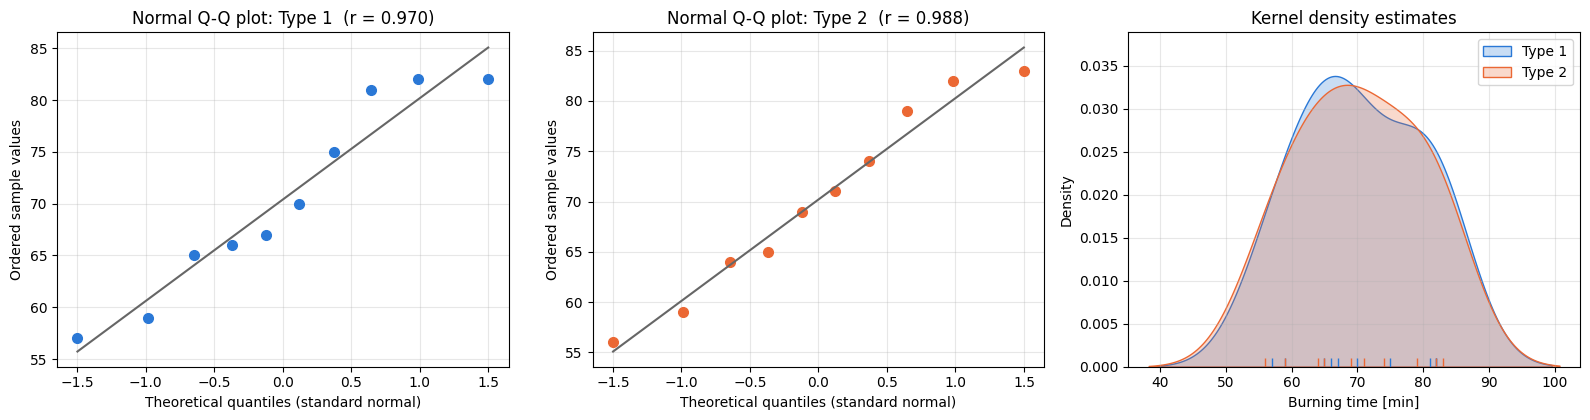

Shapiro-Wilk Type 1: W = 0.9136, P-value = 0.307
Shapiro-Wilk Type 2: W = 0.9548, P-value = 0.725


In [22]:
# 3) normality of the burning times of both types of flares
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
qq_plot(axes[0], y1, "Type 1", COL_A)
qq_plot(axes[1], y2, "Type 2", COL_B)
sns.kdeplot(y1, fill=True, color=COL_A, label="Type 1", ax=axes[2])
sns.kdeplot(y2, fill=True, color=COL_B, label="Type 2", ax=axes[2])
sns.rugplot(y1, color=COL_A, ax=axes[2])
sns.rugplot(y2, color=COL_B, ax=axes[2])
axes[2].set(xlabel="Burning time [min]", title="Kernel density estimates")
axes[2].legend()
plt.tight_layout()
plt.show()

for data, label in [(y1, "Type 1"), (y2, "Type 2")]:
    W, p_sw = shapiro(data)
    print(f"Shapiro-Wilk {label}: W = {W:.4f}, P-value = {p_sw:.3f}")

sigma = Sp = 9.315 min
Power to detect a difference of 2 min with n = 10 per group: 0.074
Sample size per group to detect a difference of 1 min with power 0.9: n = 1824.6  ->  1825
   Delta =   1.0 min  ->  n =  1825 per group
   Delta =   2.0 min  ->  n =   457 per group
   Delta =   3.0 min  ->  n =   204 per group
   Delta =   4.0 min  ->  n =   115 per group
   Delta =   5.0 min  ->  n =    74 per group
   Delta =   7.5 min  ->  n =    34 per group
   Delta =  10.0 min  ->  n =    20 per group
   Delta =  12.5 min  ->  n =    13 per group
   Delta =  15.0 min  ->  n =    10 per group


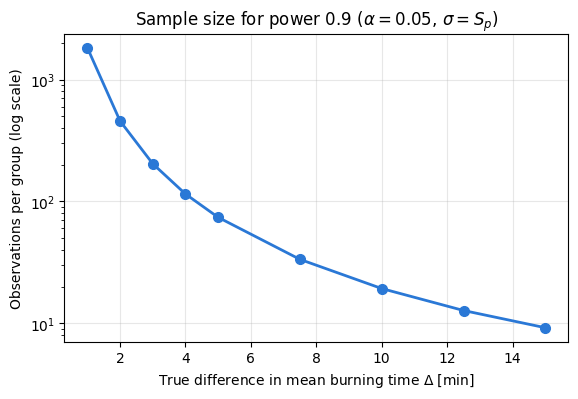

In [23]:
# 4) power for a true difference of 2 minutes, and sample size for a difference of 1 minute
analysis = TTestIndPower()
sigma_hat = r["sp"]

power_2 = analysis.power(effect_size=2 / sigma_hat, nobs1=n1, ratio=n2 / n1, alpha=alpha, alternative="two-sided")
print(f"sigma = Sp = {sigma_hat:.3f} min")
print(f"Power to detect a difference of 2 min with n = {n1} per group: {power_2:.3f}")

n_req = analysis.solve_power(effect_size=1 / sigma_hat, alpha=alpha, power=0.9, alternative="two-sided")
print(f"Sample size per group to detect a difference of 1 min with power 0.9: n = {n_req:.1f}  ->  {int(np.ceil(n_req))}")

# how the required sample size depends on the difference we want to detect
deltas = np.array([1, 2, 3, 4, 5, 7.5, 10, 12.5, 15])
n_needed = [analysis.solve_power(effect_size=d / sigma_hat, alpha=alpha, power=0.9) for d in deltas]
for d, nn in zip(deltas, n_needed):
    print(f"   Delta = {d:5.1f} min  ->  n = {int(np.ceil(nn)):5d} per group")
plt.figure(figsize=(6.5, 4))
plt.plot(deltas, n_needed, "o-", color=COL_A, lw=2, ms=7)
plt.yscale("log")
plt.xlabel(r"True difference in mean burning time $\Delta$ [min]")
plt.ylabel("Observations per group (log scale)")
plt.title(r"Sample size for power 0.9 ($\alpha = 0.05$, $\sigma = S_p$)")
plt.show()

**Conclusions (Exercise 2.26)**

1. **Variances.** $S_1^2 = 85.8$, $S_2^2 = 87.7$, $F_0 = 0.978$ with (9, 9) degrees of freedom, $P = 0.97$. $F_0$ lies well inside the acceptance region $(0.248,\ 4.03)$, so we **do not reject** $\sigma_1^2 = \sigma_2^2$; Levene's and Bartlett's tests agree. The two formulations have essentially the same variability of burning time.
2. **Means.** Using the pooled $t$-test: $\bar y_1 - \bar y_2 = 0.2$ min, $S_p = 9.32$ min, $t_0 = 0.048$ with 18 degrees of freedom, **$P$-value $= 0.96$**. We **do not reject** $\mu_1 = \mu_2$. The 95% confidence interval $(-8.6,\ 9.0)$ min shows that the data are nevertheless consistent with a difference of several minutes in either direction.
3. **Normality.** Both the $F$-test and the $t$-test are derived under normality. The $t$-test is robust to moderate non-normality (the sample means are approximately normal by the central limit theorem), but the $F$-test for variances is **very sensitive** to it: its true size depends strongly on the kurtosis of the distribution, so non-normal data can produce a spurious rejection or acceptance. Since the choice of the test in part 2 depends on part 1, normality matters here. The Q-Q plots are reasonably linear, the KDEs show no outliers and Shapiro-Wilk gives $P = 0.31$ and $0.73$, so there is no evidence against normality for either type (with $n = 10$ only gross departures could be detected). Had normality been doubtful, Levene's test and Welch's or a distribution-free test would be preferable.
4. **Power.** With $\sigma = S_p = 9.3$ min, a true difference of 2 min is a tiny effect ($d = 0.21$) and the power of the test with $n = 10$ per group is only **0.074**. To detect a 1-minute difference with power 0.9 we would need about **1825 flares per group**. Differences of 1–2 minutes are negligible compared with the spread of the burning times (SD ≈ 9 min): with 10 flares per group the experiment can reliably detect only differences of roughly 15 min, and about 10 min would already need ≈ 20 flares per group. Detecting such small effects would require either an unrealistically large experiment or a reduction of the variability (e.g. by blocking).

### Exercise 2.30

Front housings for cell phones are manufactured in an injection molding process. The time the part is allowed to cool in the mold before removal is thought to influence the occurrence of a particularly troublesome cosmetic defect, flow lines, in the finished housing. After manufacturing, the housings are inspected visually and assigned a score between 1 and 10 based on their appearance, with 10 corresponding to a perfect part and 1 corresponding to a completely defective part. An experiment was conducted using two cool-down times, 10 and 20 seconds, and 20 housings were evaluated at each level of cool-down time. All 40 observations in this experiment were run in random order.

Cool-down time 10 seconds:

| | | | |
|---|---|---|---|
| 1 | 3 | 2 | 6 |
| 1 | 5 | 3 | 3 |
| 5 | 2 | 1 | 1 |
| 5 | 6 | 2 | 8 |
| 3 | 2 | 5 | 3 |

Cool-down time 20 seconds:

| | | | |
|---|---|---|---|
| 7 | 6 | 8 | 9 |
| 5 | 5 | 9 | 7 |
| 5 | 4 | 8 | 6 |
| 6 | 8 | 4 | 5 |
| 6 | 8 | 7 | 7 |

* Is there evidence to support the claim that the longer cool-down time results in fewer appearance defects? Use $\alpha = 0.05$.
* What is the P-value for the test conducted in the previous part?
* Find a 95 percent confidence interval on the difference in means. Provide a practical interpretation of this interval.
* Compute the power of the test.

In [24]:
# Read the data from the URL
url_30 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_30.csv"
df30 = pd.read_csv(url_30, sep=";")

# Display the first few rows of the dataframe
df30.head()

,10 seconds,20 seconds
0,1,7
1,2,8
2,1,5
3,3,9
4,5,5


**Solution:**

**Hypotheses.** A higher score means a better-looking part, so "the longer cool-down time results in fewer appearance defects" means a higher mean score at 20 s. Let $\mu_{10}, \mu_{20}$ be the mean scores at the two cool-down times:

$$H_0:\ \mu_{20} = \mu_{10} \qquad\text{vs.}\qquad H_1:\ \mu_{20} > \mu_{10} .$$

This is a one-sided (upper-tail) two-sample $t$-test; we first check whether the variances can be pooled. Reject $H_0$ at $\alpha = 0.05$ if $t_0 > t_{0.05,\,38} = 1.686$.

In [25]:
y10 = df30["10 seconds"].to_numpy(dtype=float)
y20 = df30["20 seconds"].to_numpy(dtype=float)
n10, n20 = len(y10), len(y20)
alpha = 0.05

print(describe(cool_10s=y10, cool_20s=y20).round(3), "\n")

# equal variances?
F0, (d1, d2), p_F = f_test_var(y10, y20)
lev = stats.levene(y10, y20, center="median")
print(f"F-test: F0 = {F0:.3f}, df = ({d1}, {d2}), P-value = {p_F:.3f};  Levene: P-value = {lev.pvalue:.3f}"
      f"  ->  equal variances {'rejected' if p_F < alpha else 'not rejected'}")

# one-sided pooled t-test of H1: mu20 > mu10
r = pooled_t(y20, y10, alpha=alpha, alternative="greater")
t_crit = t.ppf(1 - alpha, r["df"])
print(f"\nybar20 - ybar10 = {r['diff']:.3f}, Sp = {r['sp']:.3f}, se = {r['se']:.3f}")
print(f"t0 = {r['t0']:.3f}, df = {r['df']}, critical value t(0.05, 38) = {t_crit:.3f}")
print(f"P-value = {r['p']:.2e}")
print(f"Reject H0 at alpha = {alpha}?  {'YES' if r['p'] < alpha else 'NO'}")

# cross-checks: scipy, Welch's test, and a distribution-free test (the scores are ordinal 1-10)
res = stats.ttest_ind(y20, y10, equal_var=True, alternative="greater")
res_w = stats.ttest_ind(y20, y10, equal_var=False, alternative="greater")
mw = stats.mannwhitneyu(y20, y10, alternative="greater")
print(f"\nscipy pooled: t = {res.statistic:.3f}, P = {res.pvalue:.2e}")
print(f"Welch:        t = {res_w.statistic:.3f}, df = {res_w.df:.1f}, P = {res_w.pvalue:.2e}")
print(f"Mann-Whitney U (H1: scores at 20 s tend to be higher): U = {mw.statistic:.0f}, P = {mw.pvalue:.2e}")

             n  mean     sd    var  min  max
cool_10s  20.0  3.35  2.007  4.029  1.0  8.0
cool_20s  20.0  6.50  1.539  2.368  4.0  9.0 

F-test: F0 = 1.701, df = (19, 19), P-value = 0.256;  Levene: P-value = 0.457  ->  equal variances not rejected

ybar20 - ybar10 = 3.150, Sp = 1.788, se = 0.566
t0 = 5.570, df = 38, critical value t(0.05, 38) = 1.686
P-value = 1.11e-06
Reject H0 at alpha = 0.05?  YES

scipy pooled: t = 5.570, P = 1.11e-06
Welch:        t = 5.570, df = 35.6, P = 1.35e-06
Mann-Whitney U (H1: scores at 20 s tend to be higher): U = 352, P = 1.77e-05


In [26]:
# 95% two-sided confidence interval on mu20 - mu10 (pooled)
r2 = pooled_t(y20, y10, alpha=alpha, alternative="two-sided")
print(f"95% CI for mu20 - mu10: ({r2['ci'][0]:.2f}, {r2['ci'][1]:.2f}) score points")
print(f"95% lower confidence bound (one-sided): mu20 - mu10 >= {r['ci'][0]:.2f}")

95% CI for mu20 - mu10: (2.01, 4.29) score points
95% lower confidence bound (one-sided): mu20 - mu10 >= 2.20


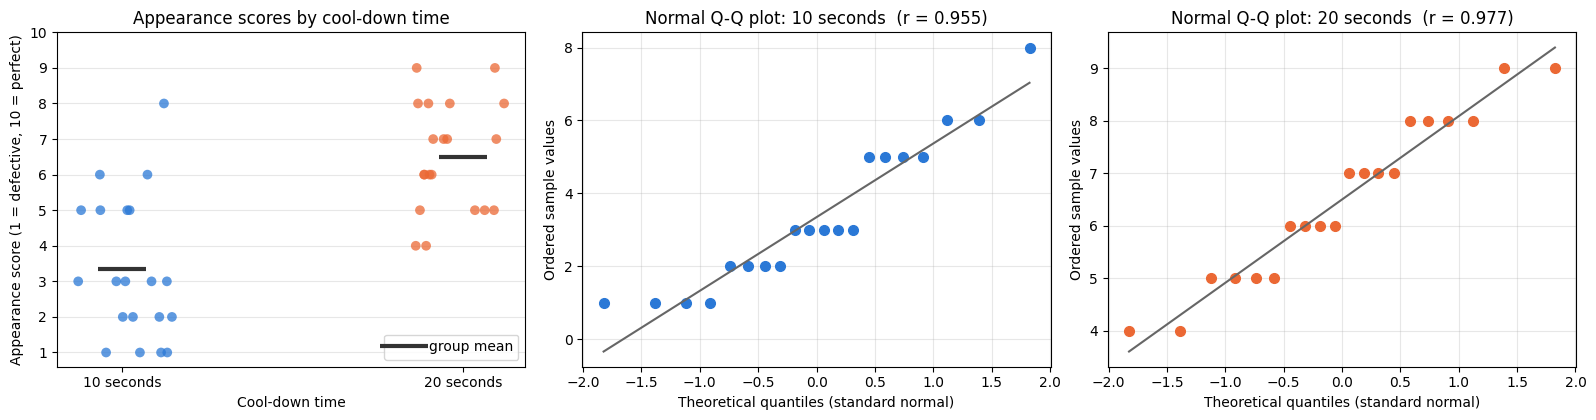

Shapiro-Wilk 10 seconds: W = 0.9034, P-value = 0.048
Shapiro-Wilk 20 seconds: W = 0.9398, P-value = 0.238


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

# individual scores (jittered) with the group means
long = df30.melt(var_name="cool-down", value_name="score")
sns.stripplot(data=long, x="cool-down", y="score", hue="cool-down", palette=[COL_A, COL_B],
              jitter=0.15, size=7, alpha=0.75, legend=False, ax=axes[0])
axes[0].plot([0, 1], [y10.mean(), y20.mean()], "_", color="0.2", ms=35, mew=3, label="group mean")
axes[0].set(xlabel="Cool-down time", ylabel="Appearance score (1 = defective, 10 = perfect)",
            title="Appearance scores by cool-down time", yticks=range(1, 11))
axes[0].legend(loc="lower right")

qq_plot(axes[1], y10, "10 seconds", COL_A)
qq_plot(axes[2], y20, "20 seconds", COL_B)
plt.tight_layout()
plt.show()

for data, label in [(y10, "10 seconds"), (y20, "20 seconds")]:
    W, p_sw = shapiro(data)
    print(f"Shapiro-Wilk {label}: W = {W:.4f}, P-value = {p_sw:.3f}")

Observed difference = 3.15, Sp = 1.788, effect size d = 1.76
Power of the one-sided test with n = 20 per group: 0.9999


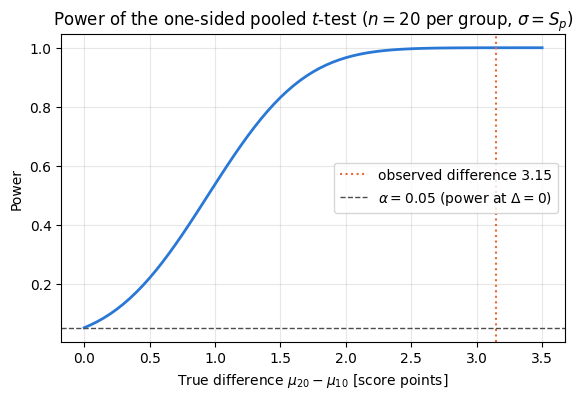

power to detect a true difference of 0.5 points: 0.219
power to detect a true difference of 1.0 points: 0.537
power to detect a true difference of 1.5 points: 0.831
power to detect a true difference of 2.0 points: 0.966


In [28]:
# power of the one-sided test, taking the observed difference and Sp as the true values
analysis = TTestIndPower()
sigma_hat = r["sp"]
d_hat = r["diff"] / sigma_hat
power_obs = analysis.power(effect_size=d_hat, nobs1=n20, ratio=n10 / n20, alpha=alpha, alternative="larger")
print(f"Observed difference = {r['diff']:.2f}, Sp = {sigma_hat:.3f}, effect size d = {d_hat:.2f}")
print(f"Power of the one-sided test with n = {n20} per group: {power_obs:.4f}")

# power as a function of the true difference in mean score
deltas = np.linspace(0, 3.5, 71)
pw = analysis.power(effect_size=deltas / sigma_hat, nobs1=n20, alpha=alpha, alternative="larger")
plt.figure(figsize=(6.5, 4))
plt.plot(deltas, pw, color=COL_A, lw=2)
plt.axvline(r["diff"], color=COL_B, ls=":", label=f"observed difference {r['diff']:.2f}")
plt.axhline(alpha, color="0.3", ls="--", lw=1, label=r"$\alpha = 0.05$ (power at $\Delta = 0$)")
plt.xlabel(r"True difference $\mu_{20} - \mu_{10}$ [score points]")
plt.ylabel("Power")
plt.title(r"Power of the one-sided pooled $t$-test ($n = 20$ per group, $\sigma = S_p$)")
plt.legend(loc="center right")
plt.show()
for d in [0.5, 1.0, 1.5, 2.0]:
    print(f"power to detect a true difference of {d:.1f} points: "
          f"{analysis.power(effect_size=d / sigma_hat, nobs1=n20, alpha=alpha, alternative='larger'):.3f}")

**Conclusions (Exercise 2.30)**

* **Test.** The mean scores are $\bar y_{10} = 3.35$ and $\bar y_{20} = 6.50$. The variances do not differ significantly ($F_0 = 1.70$, $P = 0.26$), so the pooled test is used: $S_p = 1.79$, $t_0 = 5.57$ with 38 degrees of freedom, far above $t_{0.05,38} = 1.69$. We **reject $H_0$**: there is strong evidence that the longer cool-down time gives higher appearance scores, i.e. fewer appearance defects.
* **P-value.** $P = 1.1 \times 10^{-6}$ (one-sided). Welch's test ($P = 1.4\times10^{-6}$) and the distribution-free Mann-Whitney test ($P = 1.8\times10^{-5}$) lead to the same conclusion, so the result does not depend on the normality or equal-variance assumptions.
* **Confidence interval.** $2.0 \le \mu_{20} - \mu_{10} \le 4.3$ score points (95%). *Practical interpretation:* increasing the cool-down time from 10 s to 20 s raises the mean appearance score by at least 2 and at most about 4.3 points on the 10-point scale, with 95% confidence. The mean moves from a mostly defective part (≈ 3.4) to a fairly good one (≈ 6.5), so the improvement is not only statistically significant but practically important; the whole interval lies far from 0.
* **Power.** For a true difference equal to the observed 3.15 points and $\sigma = S_p = 1.79$ (effect size $d = 1.76$), the power with 20 housings per group is **0.9999**: an effect of this size would essentially never be missed. The power curve shows that even a true difference of 1 point would be detected with probability about 0.54, and 1.5 points with probability about 0.83.
* **Remark on the assumptions.** The scores are discrete ordinal values from 1 to 10. The 10-second sample is skewed towards low scores and bounded at 1 (Shapiro-Wilk $P = 0.048$), the 20-second sample looks normal ($P = 0.24$). With $n = 20$ per group the $t$-test is robust to this, and the Mann-Whitney test confirms the conclusion.

## Summary

| Exercise | Test | Statistic | $P$-value | Decision ($\alpha$) | Interval |
|---|---|---|---|---|---|
| 2.20 shelf life | one-sample $t$, $H_1: \mu > 120$ | $t_0 = 1.78$ (df 9) | 0.054 | $H_0$ not rejected (0.01) | 99% CI $(110.9,\ 151.1)$ days |
| 2.21 etch rate | pooled $t$, $H_1: \mu_1 \ne \mu_2$ | $t_0 = -2.30$ (df 14) | 0.037 | $H_0$ rejected (0.05) | 95% CI $(-0.80,\ -0.03)$ mils/min |
| 2.26 flares, variances | $F$, $H_1: \sigma_1^2 \ne \sigma_2^2$ | $F_0 = 0.98$ (df 9, 9) | 0.97 | $H_0$ not rejected (0.05) | – |
| 2.26 flares, means | pooled $t$, $H_1: \mu_1 \ne \mu_2$ | $t_0 = 0.05$ (df 18) | 0.96 | $H_0$ not rejected (0.05) | 95% CI $(-8.6,\ 9.0)$ min |
| 2.30 cool-down | pooled $t$, $H_1: \mu_{20} > \mu_{10}$ | $t_0 = 5.57$ (df 38) | $1.1\times10^{-6}$ | $H_0$ rejected (0.05) | 95% CI $(2.0,\ 4.3)$ points |

Power: 2.21 – power 0.57 for the observed difference, $n = 31$ per group for $\Delta = 0.3$ at power 0.9; 2.26 – power 0.07 for $\Delta = 2$ min, $n \approx 1825$ per group for $\Delta = 1$ min; 2.30 – power ≈ 1 for the observed difference.